# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [4]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [5]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_ratio = df.isnull().mean() * 100
print("Tỷ lệ missing của từng cột:")
print(missing_ratio.round(2))
print("\n")

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']  # điền danh sách cột cần bỏ
df = df.drop(columns=leaky, errors='ignore')

print("Các cột còn lại:", list(df.columns))
print("Shape:", df.shape)

Tỷ lệ missing của từng cột:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Shape: (891, 8)


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

alive là bản sao trực tiếp của survived (0->no và 1->yes) nên nếu để lại thì mô hình sẽ học ánh xạ đơn giản này, đạt accuracy tiến dần về 100%. Nhưng mô hình thực tế không học được quy luật hay quan hệ nào, sẽ vô dụng nếu gặp dữ liệu mới không có [alive].

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [17]:
# TODO 2: shape, info, describe
print("SHAPE")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"Biến mục tiêu (target): 'survived'")
print("\n")

print("INFO")
print(df.info())
print("\n")

print("DESCRIBE - Biến số")
print(df.describe())
print("\n")

print("DESCRIBE - Biến phân loại")
print(df.describe(include=['object', 'category']))

SHAPE
Số dòng: 891
Số cột: 8
Biến mục tiêu (target): 'survived'


INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None


DESCRIBE - Biến số
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.00

C:\Users\PHUC\AppData\Local\Temp\ipykernel_12068\2757651544.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object', 'category']))


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*

biến số: survived, pclass, age, sibsp, parch, fare có thể thực hiện các phép toán số học, có giá trị liên tục hoặc đếm được.
biến phân loại: sex, embarked ở dạng chữ hoặc danh mục, không có thứ tự về mặt số học.


---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [7]:
# TODO 3: bảng missing (count + %)
missing_df = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Số lượng thiếu': missing_df,
    'Phần trăm (%)': missing_percent.round(2)
})
missing_table = missing_table[missing_table['Số lượng thiếu'] > 0].sort_values('Phần trăm (%)', ascending=False)
print("BẢNG THỐNG KÊ GIÁ TRỊ THIẾU:")
print(missing_table)

BẢNG THỐNG KÊ GIÁ TRỊ THIẾU:
          Số lượng thiếu  Phần trăm (%)
age                  177          19.87
embarked               2           0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.87% | Điền median theo từng nhóm (pclass,sex) | median bền vừng với outlier, tuổi có phụ thuộc vào hạng vé và giới tính |
| fare | 0.15% | Điền median | giá vé lệch phải có nhiều outlier(mắc) nên median an toàn nhất |
| embarked | 0.15% | Điền mode | vì thiếu rất ít nên chọn cảng đông nhất cho an toàn |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [18]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s_clean = s.dropna()
    Q1 = s_clean.quantile(0.25)
    Q3 = s_clean.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((s_clean < lower_bound) | (s_clean > upper_bound)).sum()
    return outlier_count

def dem_outlier_zscore(s, nguong=3.0):
    s_clean = s.dropna()
    z_scores = np.abs(stats.zscore(s_clean))
    outlier_count = (z_scores > nguong).sum()
    return outlier_count

for col in ["age", "fare"]:
    iqr_out = dem_outlier_iqr(df[col])
    z_out = dem_outlier_zscore(df[col])
    print(f"{col}:")
    print(f"  - Số outlier theo IQR: {iqr_out}")
    print(f"  - Số outlier theo Z-score: {z_out}")
    print()

age:
  - Số outlier theo IQR: 11
  - Số outlier theo Z-score: 2

fare:
  - Số outlier theo IQR: 116
  - Số outlier theo Z-score: 20



**Trả lời 4 (quyết định với outlier của `fare`):**

Không loại bỏ outlier của fare vì nó thể hiện được sự đa dạng trong giá vé (sự khác biệt giữa hạng 1-3). Thêm vào đó, thông tin giá vé có tương quan với pclass và survive nên giữ các giá trị này sẽ cung cấp chi tiết hơn về nhóm khách hàng hạng 1 có tỉ lệ sống sót cao nhất. Đây là mối quan hệ thực tế, không phải nhiễu.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

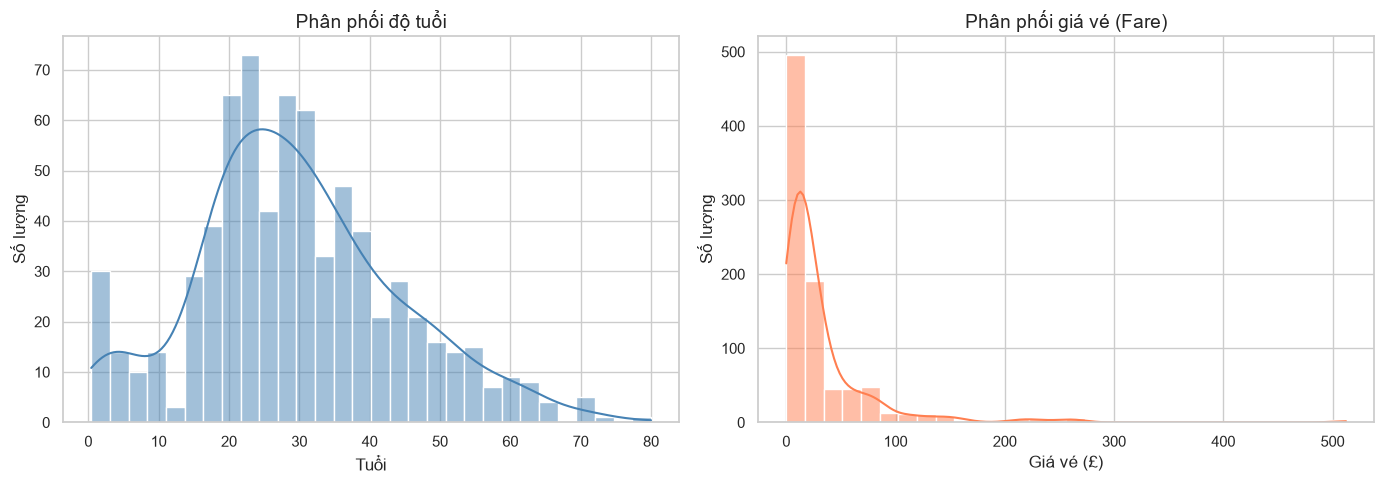

In [19]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối độ tuổi', fontsize=14)
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số lượng')

sns.histplot(df['fare'].dropna(), bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Phân phối giá vé (Fare)', fontsize=14)
axes[1].set_xlabel('Giá vé (£)')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

C:\Users\PHUC\AppData\Local\Temp\ipykernel_12068\1340437212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
C:\Users\PHUC\AppData\Local\Temp\ipykernel_12068\1340437212.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='fare', data=df, ax=axes[1], palette='Set2')


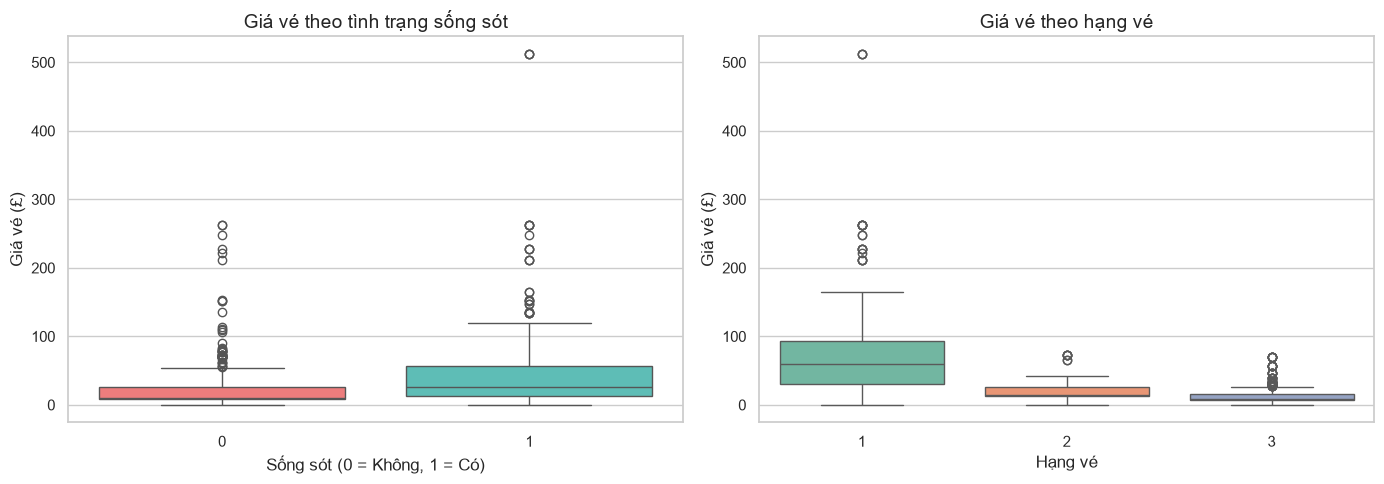

In [20]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='survived', y='fare', data=df, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Giá vé theo tình trạng sống sót', fontsize=14)
axes[0].set_xlabel('Sống sót (0 = Không, 1 = Có)')
axes[0].set_ylabel('Giá vé (£)')

sns.boxplot(x='pclass', y='fare', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Giá vé theo hạng vé', fontsize=14)
axes[1].set_xlabel('Hạng vé')
axes[1].set_ylabel('Giá vé (£)')

plt.tight_layout()
plt.show()

C:\Users\PHUC\AppData\Local\Temp\ipykernel_12068\2242712881.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=surv_by_sex.index, y=surv_by_sex.values, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
C:\Users\PHUC\AppData\Local\Temp\ipykernel_12068\2242712881.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=surv_by_class.index, y=surv_by_class.values, ax=axes[1], palette='Set2')


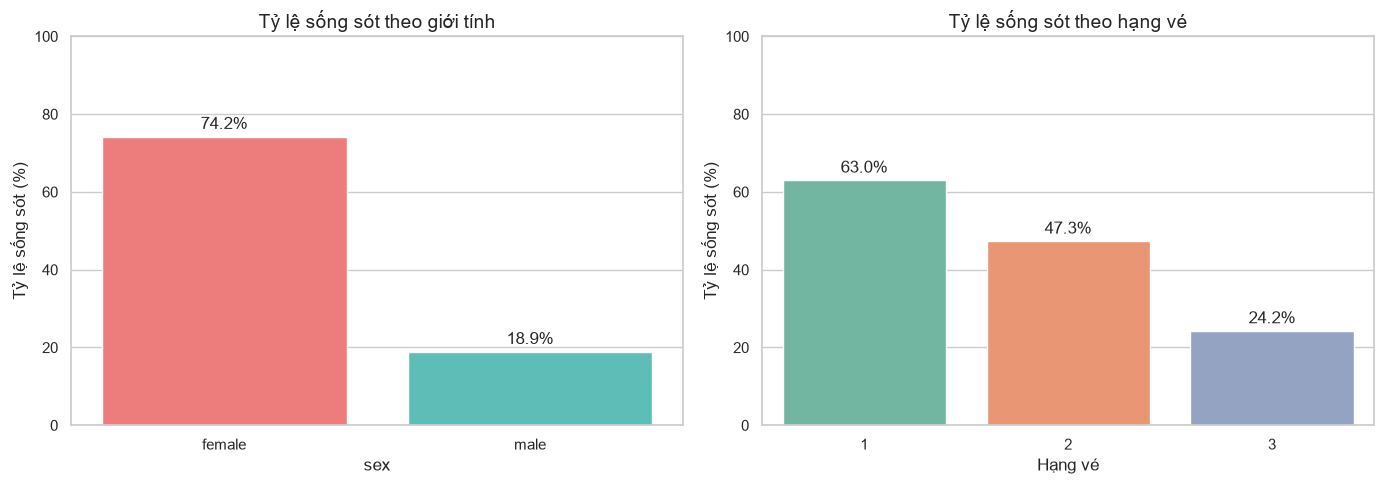

In [21]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surv_by_sex = df.groupby('sex')['survived'].mean() * 100
sns.barplot(x=surv_by_sex.index, y=surv_by_sex.values, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Tỷ lệ sống sót theo giới tính', fontsize=14)
axes[0].set_ylabel('Tỷ lệ sống sót (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(surv_by_sex.values):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12)

surv_by_class = df.groupby('pclass')['survived'].mean() * 100
sns.barplot(x=surv_by_class.index, y=surv_by_class.values, ax=axes[1], palette='Set2')
axes[1].set_title('Tỷ lệ sống sót theo hạng vé', fontsize=14)
axes[1].set_xlabel('Hạng vé')
axes[1].set_ylabel('Tỷ lệ sống sót (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(surv_by_class.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

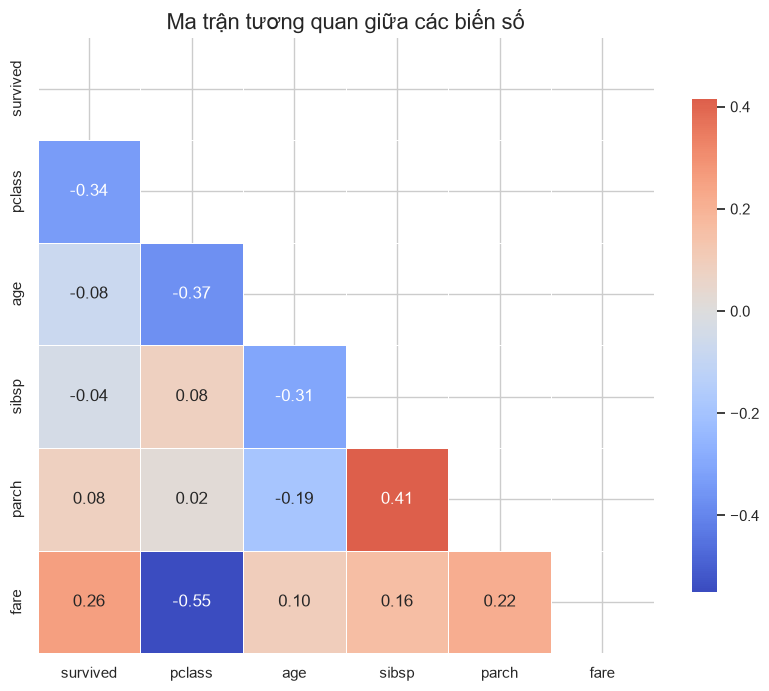

In [22]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến số', fontsize=16)
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Cả phân phối tuổi và giá vé đều lệch phải. Tuổi thì tập trung nhiều ở 20-40, giá vé thì có một đuôi dài bên phải, chứng tỏ một vài vé mắc nhất đắt hơn rất nhiều lần các vé thông thường.
- Boxplot: Những người sống sót có median fare cao hơn đáng kể so với người không sống sót. Có nhiều outlier ở cả hai nhóm, đặc biệt là nhóm sống sót có vé rất đắt. Fare tăng rõ ràng giữa các hạng vé.
- Bar survival: Phụ nữ có tỷ lệ sống sót ~74%, trong khi nam giới chỉ ~19%. Em xem phim titanic thì thấy "Women and children first" khi sơ tán nên thấy tỉ lệ này không đáng ngạc nhiên.
- Heatmap: pclass và fare tương quan âm (mắc hơn - số nhỏ) thể hiện người lớn tuổi hơn thường có vé hạng cao hơn. sibsp và parch tương quan dương do gia đình đông có xu hướng đi cùng nhau

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [23]:
# TODO 6: chia train/val/test có stratify
X = df.drop('survived', axis=1)
y = df['survived']

# tách 15%
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# tách val từ phần còn lại (85% còn lại -> train 70%, val 15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, random_state=42, stratify=y_tmp
)

print("Kích thước các tập:")
print(f"Train: {X_train.shape} - Tỷ lệ sống sót: {y_train.mean():.2%}")
print(f"Val:   {X_val.shape} - Tỷ lệ sống sót: {y_val.mean():.2%}")
print(f"Test:  {X_test.shape} - Tỷ lệ sống sót: {y_test.mean():.2%}")
print(f"\nTổng:  {len(X)} mẫu")

Kích thước các tập:
Train: (623, 7) - Tỷ lệ sống sót: 38.36%
Val:   (134, 7) - Tỷ lệ sống sót: 38.81%
Test:  (134, 7) - Tỷ lệ sống sót: 38.06%

Tổng:  891 mẫu


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [25]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop='first', handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))
print(X_val_t.shape, list(preprocess.get_feature_names_out()))
print(X_test_t.shape, list(preprocess.get_feature_names_out()))

(623, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']
(134, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']
(134, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Nếu fit trên toàn bộ dữ liệu, tập test đã bị học các tham số của preprocess. Vậy nên khi chỉ fit trên train, các tham số được học hoàn toàn từ train. Tập train và valid chỉ được áp dụng trên các tham số đã train, đảm bảo tính trung thực và tính chính xác nếu gặp test mới

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [26]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
survived_counts = df['survived'].value_counts()
survived_percent = df['survived'].value_counts(normalize=True) * 100

print("Phân phối biến mục tiêu 'survived':")
print(f"Không sống sót (0): {survived_counts[0]} hành khách ({survived_percent[0]:.1f}%)")
print(f"Sống sót (1):     {survived_counts[1]} hành khách ({survived_percent[1]:.1f}%)")
print(f"\nTỷ lệ sống sót: {survived_percent[1]:.1f}%")

Phân phối biến mục tiêu 'survived':
Không sống sót (0): 549 hành khách (61.6%)
Sống sót (1):     342 hành khách (38.4%)

Tỷ lệ sống sót: 38.4%


**Trả lời 8:**

1. Có mất cân bằng nhẹ (xấp xỉ 2:3)
2. Khi mô hình bị lệch nặng (vd tỉ lệ sống là 1/20) thì mô hình luôn luôn đoán đã chết sẽ cho tỉ lệ đúng của accuracy tận 95%.
3. Nếu muốn phát hiện nhiều trường hợp sống nhất thì Recall, muốn chính xác nhất thì F1-score

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Tương quan dương cao nhất với khả năng sống sót là giới tính (nứ 0.74 - nam 0.19) và hạng vé (tương quan -0.34 ở đây là do hạng vé đếm ngược từ 3->1)
2. age thiếu ~20%: được điền bằng median theo từng nhóm (pclass, sex) để phản ánh đặc điểm nhóm. fare và embarked thiếu rất ít (0.15%), làm biếng thì mode cho lẹ còn cổ điển tôn trọng thì median cho fare.
3. Biến mục tiêu tương đối cân bằng so với một dữ liệu thực tế (0.4:0.6), với em thì lệch là phải tầm (0.25:0.75), tùy mục đích mà sử dụng Recall hay F1.
4. age, fare, sibsp, parch cần scaling vì có đơn vị đo khác nhau và khoảng giá trị khác biệt (fare từ 0-500, age từ 0-80).
Sử dụng RobustScaler vì fare có nhiều outlier.
sex và embarked là biến phân loại cần OneHotEncoding.
pclass giữ nguyên vì là số thứ tự.
5. Em ấn tượng tỉ lệ sống sót của nữ cao hơn hẳn nam, ý là rõ ràng đã có chính xác women/children first, nhưng mà rất cổ điển tôn trọng cho đàn ông vì thật sự đã không giành lên xuống cứu sinh trong tình huống đó, điều mà họ thừa sức làm vì đàn ông có sức khỏe trung bình tốt hơn phụ nữ.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [16]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
